In [44]:
%load_ext autoreload
%autoreload 2
import pandas as pd
from archifer.model import BuildingSector

archetype_df = pd.read_excel("../data/building_stock_archetypes.xlsx", index_col=0)

bs = BuildingSector(archetype_df)
bs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Status: Optimal


<Axes: title={'center': 'Optimization result'}, xlabel='NFA'>

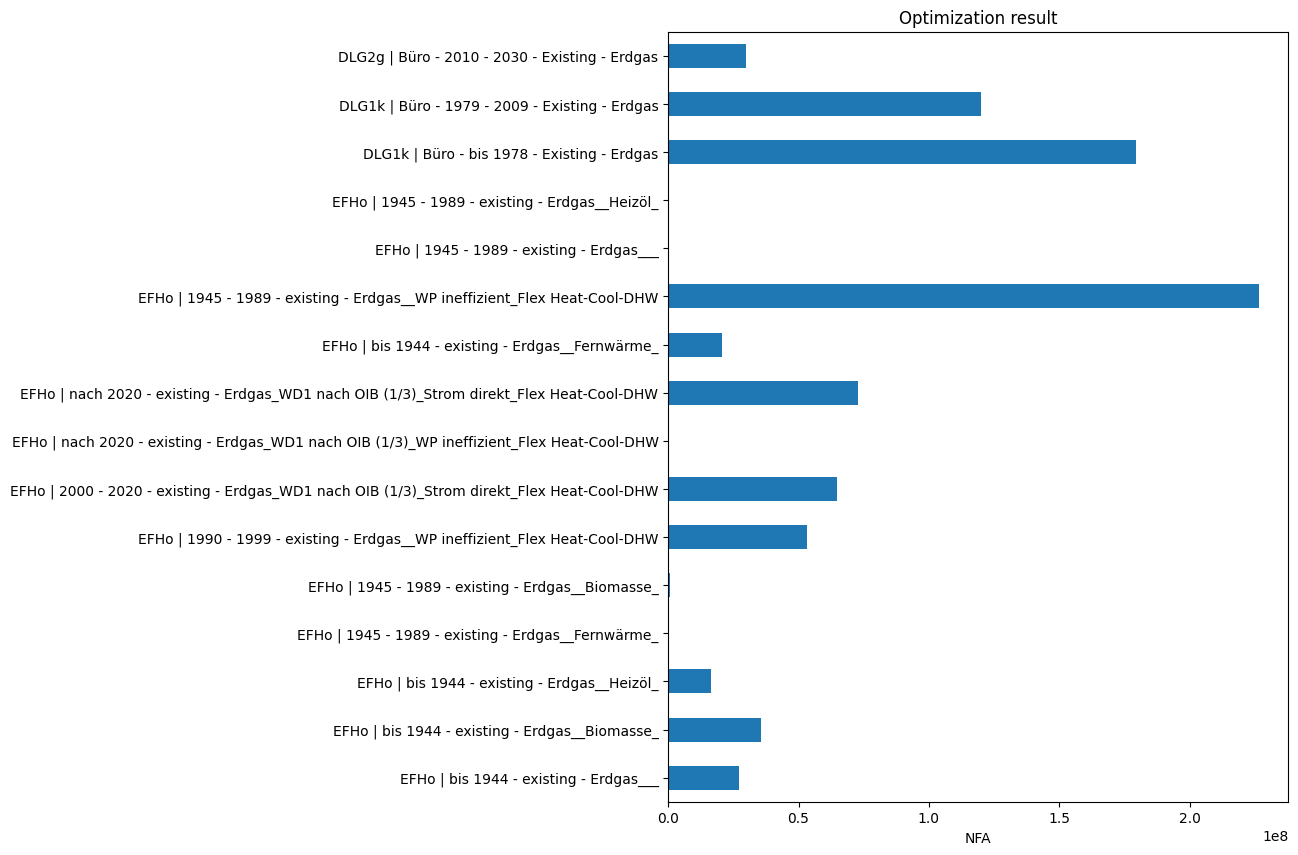

In [45]:
bs.clear_constraints()
ngf_constraints_df = pd.read_excel("../data/constraints_sector_model.xlsx", sheet_name="NGF_simplified")
ee_constraints_df = pd.read_excel("../data/constraints_sector_model.xlsx", sheet_name="EE")

ngf_filter_cols = [
    "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)",
    "Building Period",
]

# For EE, the constraints use building use and sometimes Energy Supply.
# If Energy Supply is empty in Excel, it is ignored for that row.
ee_filter_cols = [
    "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)",
    "Energy Supply",
]

bs.add_constraints_from_df(
    constraints_df=ngf_constraints_df,
    filter_cols=ngf_filter_cols,
    weight=1_000_000,
    name_prefix="NGF",
)

bs.add_constraints_from_df(
    constraints_df=ee_constraints_df,
    filter_cols=ee_filter_cols,
    weight=1_000,
    name_prefix="EE",
)


bs.solve()
bs.plot_result()


In [46]:
bs.archetypes["Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)"]

ID
1           Unter 200 Quadratmeter
2           Unter 200 Quadratmeter
3           Unter 200 Quadratmeter
4           Unter 200 Quadratmeter
5           Unter 200 Quadratmeter
                   ...            
2894        Unter 200 Quadratmeter
2895      300 bis 500 Quadratmeter
2896      300 bis 500 Quadratmeter
2897    1000 Quadratmeter und mehr
2898    1000 Quadratmeter und mehr
Name: Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1), Length: 2898, dtype: object

In [47]:
shares_df = pd.read_excel("../data/constraints_sector_model.xlsx", sheet_name="shares")
shares_df


,Geometry,Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),target_column,target_value
0,EFHo,Unter 200 Quadratmeter,NaN,0.50
1,EFHo,200 bis 300 Quadratmeter,NaN,0.45
2,EFHo,300 bis 500 Quadratmeter,NaN,0.05
3,EFHo,500 bis 1 000 Quadratmeter,NaN,0.00
4,EFHo,1000 Quadratmeter und mehr,NaN,0.00
5,EFHk,Unter 200 Quadratmeter,NaN,0.50
6,EFHk,200 bis 300 Quadratmeter,NaN,0.45
7,EFHk,300 bis 500 Quadratmeter,NaN,0.05
8,EFHk,500 bis 1 000 Quadratmeter,NaN,0.00
9,EFHk,1000 Quadratmeter und mehr,NaN,0.00


In [48]:
shares_filter_cols = [
    "Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)",
    "Geometry",
]
shares_reference_cols = ["Geometry"]

bs.add_constraints_from_df(
    constraints_df=shares_df,
    filter_cols=shares_filter_cols,
    weight=1_000_000,
    name_prefix="Shares",
    reference_cols=shares_reference_cols,
    type="share"

)


In [52]:
l = bs.constraints[-29]
l

Constraint(name='Shares_1', filter={'Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)': '200 bis 300 Quadratmeter', 'Geometry': 'EFHo'}, column=None, target=0.45, weight=1000000, type='share', reference_filter={'Geometry': 'EFHo'})

In [60]:
res_df = pd.read_excel("../data/constraints_sector_model.xlsx", sheet_name="res")
res_df


,Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),target_column,target_value
0,Wohngebäude,NaN,0.584


In [61]:

res_filter_cols = [
    "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)",
]
res_reference_cols = []

bs.add_constraints_from_df(
    constraints_df=res_df,
    filter_cols=res_filter_cols,
    weight=1_000_000,
    name_prefix="res",
    reference_cols=res_reference_cols,
    type="share"

)

Skipping Shares_1: no matching archetypes
Skipping Shares_2: no matching archetypes
Skipping Shares_3: no matching archetypes
Skipping Shares_4: no matching archetypes
Skipping Shares_6: no matching archetypes
Skipping Shares_7: no matching archetypes
Skipping Shares_8: no matching archetypes
Skipping Shares_9: no matching archetypes
Skipping Shares_10: no matching archetypes
Skipping Shares_11: no matching archetypes
Skipping Shares_13: no matching archetypes
Skipping Shares_14: no matching archetypes
Skipping Shares_15: no matching archetypes
Skipping Shares_16: no matching archetypes
Skipping Shares_18: no matching archetypes
Skipping Shares_19: no matching archetypes
Skipping Shares_20: no matching archetypes
Skipping Shares_21: no matching archetypes
Skipping Shares_22: no matching archetypes
Skipping Shares_23: no matching archetypes
Skipping Shares_25: no matching archetypes
Skipping Shares_26: no matching archetypes
Skipping Shares_27: no matching archetypes
Skipping Shares_28:

<Axes: title={'center': 'Optimization result'}, xlabel='NFA'>

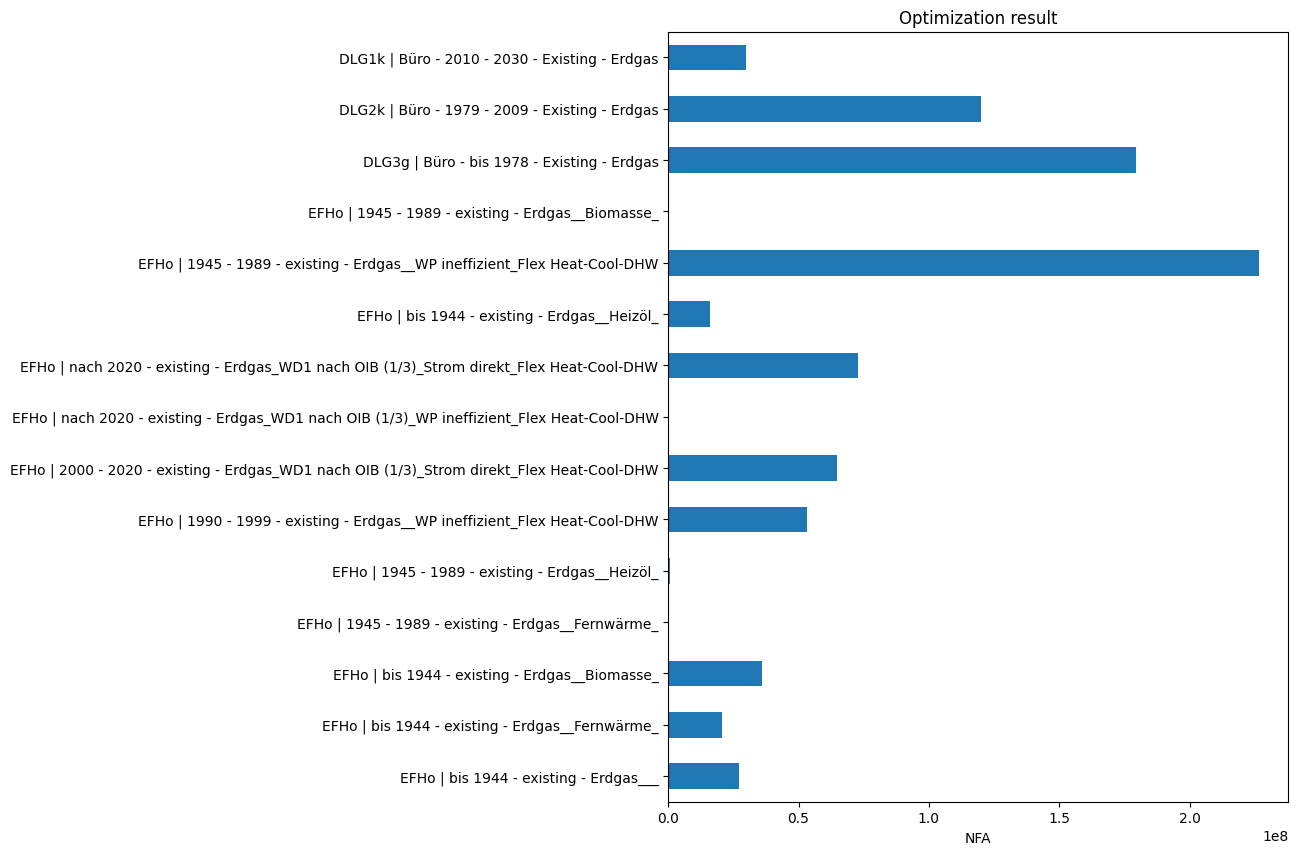

In [62]:

bs.solve()
bs.plot_result()

In [63]:
df =bs.result_df()
df = df[df["NFA"] > 0]
df

,Total Net floor Area,Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Geometry,m²NGF,Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Building Period,Bauperiode (Ebene +2),Building Quality,renovated,thermisch wirksame Speichermasse,...,WW Endenergiebedarf Elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW Hilfsstrom__,WW 1 Endenergie thermisch__kWh/m²NGFa,WW 1 Endenergie elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW 1 Hilfsstrom__kWh/m²NGFa,WW 2 Endenergie thermisch__kWh/m²NGFa,WW 2 Endenergie elektrisch (inkl.Hilfsstrom)__kWh/m²NGFa,WW 2 Hilfsstrom__kWh/m²NGFa,buildings,NFA
ID,,,,,,,,,,,,,,,,,,,,,
1,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,original,0,mittel (124 Wh/m²K),...,0.798780,0.798780,15.975610,0.798780,0.798780,0,0,0,27228737.0,27228737.0
5,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,original,0,mittel (124 Wh/m²K),...,0.887530,0.887530,17.750610,0.887530,0.887530,0,0,0,20465459.0,20465459.0
33,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,original,0,mittel (124 Wh/m²K),...,0.887530,0.887530,17.750610,0.887530,0.887530,0,0,0,36052280.0,36052280.0
293,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,1945 - 1989,1945 bis 1960,original,0,mittel (124 Wh/m²K),...,0.887530,0.887530,17.750610,0.887530,0.887530,0,0,0,4.0,4.0
333,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,1945 - 1989,1945 bis 1960,original,0,mittel (124 Wh/m²K),...,0.887530,0.887530,17.750610,0.887530,0.887530,0,0,0,861023.0,861023.0
597,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,1990 - 1999,1991 bis 2000,original,0,mittel (124 Wh/m²K),...,7.988041,0.887530,17.750610,7.988041,0.887530,0,0,0,53330641.0,53330641.0
906,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,2000 - 2020,2001 bis 2010,OIB_1/3,1,mittel (124 Wh/m²K),...,0.798780,0.798780,15.975610,0.798780,0.798780,0,0,0,64783868.0,64783868.0
1174,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,nach 2020,2011 und später,OIB_1/3,0,mittel (124 Wh/m²K),...,7.988140,0.887530,17.750610,7.988140,0.887530,0,0,0,18.0,18.0
1194,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,nach 2020,2011 und später,OIB_1/3,0,mittel (124 Wh/m²K),...,0.798780,0.798780,15.975610,0.798780,0.798780,0,0,0,72758792.0,72758792.0


<Axes: ylabel='name'>

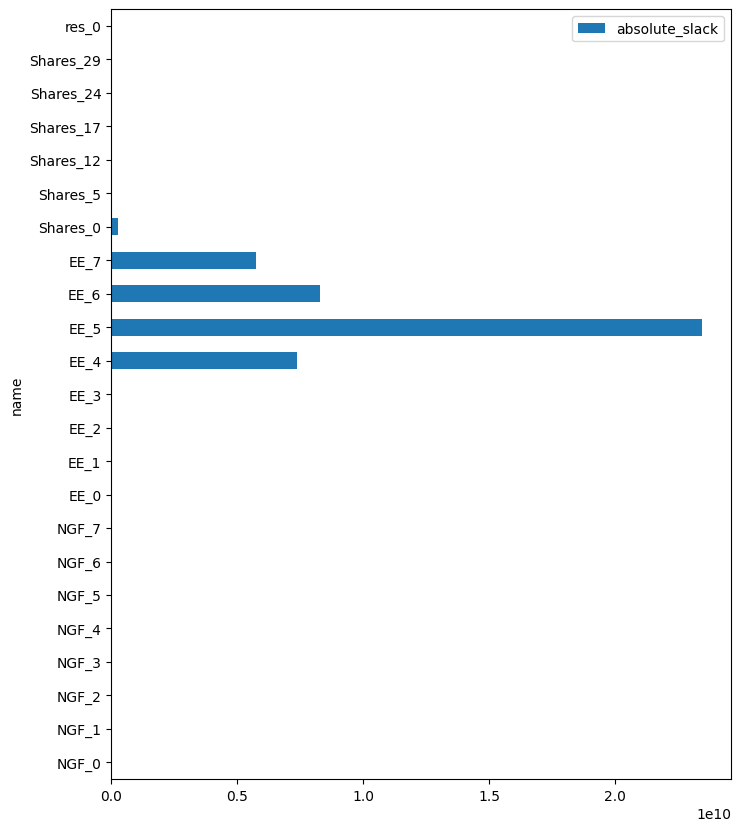

In [64]:
slacks = bs.slack_df()
slacks.head()
slacks.plot(
    x="name",
    y="absolute_slack",
    kind="barh",
    figsize=(8, 10),
)